In [1]:
from google.colab import drive
drive.mount('/content/drive')
import os
os.chdir('/content/drive/MyDrive/frontiers-rev')
print("Current directory files:", os.listdir('.'))

Mounted at /content/drive
Current directory files: ['Manuscript_v1.PDF', 'Reviewer_Comments.pdf', 'Frontiers in Big Data - Reviewer Comments.gdoc', 'figure_table_comparison_top_ses', 'spatial_autocorrelation_check', 'Frontiers_rev_results.gdoc', 'SupMaterial_v1.PDF', 'parameter_values_ses_cluster_comparison_2019.csv', 'nyc_cbgs.json', 'NY_cbg_census.csv', 'PSO_2019_6params_NYC_norm_28_PSO_15.csv', 'PSO_2018_6params_NYC_norm_28_PSO_15.csv', 'PSO_2020_6params_NYC_norm_28_PSO_15.csv', 'PSO_2021_6params_NYC_norm_28_PSO_15.csv', 'kmeans_stability_nyc_cbgs_results.csv', 'kmeans_stability_inertia_table.csv', 'kmeans_stability_ari_table.csv', 'kmeans_stability_cluster_centers.csv', 'kmeans_stability_cluster_sizes.csv', 'cbg_parameter_changes_for_moran.csv', 'moran_global_parameter_changes.csv', 'lisa_local_parameter_changes.csv', 'reviewer_comments_PCA_20260601.ipynb', 'Copy of reviewer_comments_PCA_20260601.ipynb']


# KMEANS

## Kmeans with standardizedattributes

Numeric columns that provide counts of each CBG residents falling under the corresponding attribute are converted to percentage before standardization



In [3]:
import random
import json
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

# ------------------------------------------------------------
# 1. Read census file and NYC CBG geojson/json file
# ------------------------------------------------------------

# NY_cbg_census.csv: This file provides census info for all CBGs in NY state
census = pd.read_csv("/content/drive/MyDrive/frontiers-rev/NY_cbg_census.csv").drop(
    columns="Unnamed: 0",
    errors="ignore"
)
print(census.columns)

with open("/content/drive/MyDrive/frontiers-rev/nyc_cbgs.json", "r") as f:
    nyc_cbgs_json = json.load(f)

print(nyc_cbgs_json["features"][0]["properties"].keys())
# ------------------------------------------------------------
# 2. Extract NYC CBG GEOID values from nyc_cbgs.json
# ------------------------------------------------------------

nyc_geoid = []

for feature in nyc_cbgs_json["features"]:
    geoid = feature["properties"].get("GEOID")
    if geoid is not None:
        nyc_geoid.append(str(geoid))

nyc_geoid = set(nyc_geoid)

print("Number of GEOID values in nyc_cbgs.json:", len(nyc_geoid))

Index(['GEOID', 'NAME', 'populationE', 'med_ageE', 'bachelor_degree_25E',
       'med_hh_incomeE', 'whiteE', 'blackE', 'asianE', 'hispanicE'],
      dtype='object')
dict_keys(['OBJECTID', 'STATEFP', 'COUNTYFP', 'TRACTCE', 'BLKGRPCE', 'GEOID', 'NAMELSAD', 'MTFCC', 'FUNCSTAT', 'ALAND', 'AWATER', 'INTPTLAT', 'INTPTLON', 'geo_id', 'OBJECTID_1', 'GEOID_1', 'SHAPE_Leng', 'SHAPE_Area'])
Number of GEOID values in nyc_cbgs.json: 6493


In [4]:
# ------------------------------------------------------------
# 3. Identify and standardize census CBG ID column
# ------------------------------------------------------------

census_cbg_col = "GEOID"

if census_cbg_col not in census.columns:
    raise ValueError(
        f"Column '{census_cbg_col}' not found. "
        "Check census.columns.tolist() and update census_cbg_col."
    )

census[census_cbg_col] = census[census_cbg_col].astype(str).str.zfill(12)

# ------------------------------------------------------------
# 4. Filter census to NYC CBGs only
# ------------------------------------------------------------

census_nyc = census[census[census_cbg_col].isin(nyc_geoid)].copy()

print("Rows in original census:", len(census))
print("Rows after filtering to NYC CBGs:", len(census_nyc))

Rows in original census: 15463
Rows after filtering to NYC CBGs: 6493


In [5]:
# ------------------------------------------------------------
# 5. Create dataframe for clustering
# ------------------------------------------------------------

df_stnd = census_nyc[
    [
        census_cbg_col,
        "populationE",
        "med_ageE",
        "med_hh_incomeE",
        "bachelor_degree_25E",
        "whiteE",
        "blackE",
        "asianE",
        "hispanicE",
    ]
].copy()

# ------------------------------------------------------------
# 6. Convert count variables to population shares
# ------------------------------------------------------------

share_cols = [
    "bachelor_degree_25E",
    "whiteE",
    "blackE",
    "asianE",
    "hispanicE",
]

df_stnd[share_cols] = df_stnd[share_cols].div(df_stnd["populationE"], axis=0)

# Replace inf values caused by zero population
df_stnd = df_stnd.replace([np.inf, -np.inf], np.nan)

# ------------------------------------------------------------
# 7. Define variables used for socioeconomic K-means clustering
# ------------------------------------------------------------

socio_cols = [
    "med_ageE",
    "bachelor_degree_25E",
    "med_hh_incomeE",
    "whiteE",
    "blackE",
    "asianE",
    "hispanicE",
]

print("\nDescriptive statistics before cleaning:")
print(df_stnd[socio_cols].describe())

print("\nMissing values before cleaning:")
print(df_stnd[socio_cols].isna().sum())

print("\nInfinite values before cleaning:")
print(np.isinf(df_stnd[socio_cols]).sum())

print("\nRows before cleaning:", len(df_stnd))

# ------------------------------------------------------------
# 8. Clean data before scaling
# ------------------------------------------------------------

df_kmeans_clean = (
    df_stnd
    .replace([np.inf, -np.inf], np.nan)
    .dropna(subset=socio_cols)
    .copy()
)

print("Rows after cleaning:", len(df_kmeans_clean))

print("\nMissing values after cleaning:")
print(df_kmeans_clean[socio_cols].isna().sum())

print("\nInfinite values after cleaning:")
print(np.isinf(df_kmeans_clean[socio_cols]).sum())

# ------------------------------------------------------------
# 9. Standardize clean data
# ------------------------------------------------------------

scaler = StandardScaler()

data_kmeans_scaled = scaler.fit_transform(df_kmeans_clean[socio_cols])

data_kmeans_scaled = pd.DataFrame(
    data_kmeans_scaled,
    columns=socio_cols,
    index=df_kmeans_clean.index,
)

print("\nMissing values after scaling:")
print(data_kmeans_scaled.isna().sum())

print("\nInfinite values after scaling:")
print(np.isinf(data_kmeans_scaled).sum())

# ------------------------------------------------------------
# 10. Run K-means under different random seeds
# ------------------------------------------------------------

k = 5
random.seed(123)
seeds = random.sample(range(1, 21000), 10)

print("\nSeeds used:")
print(seeds)

results = {}

for seed in seeds:
    kmeans = KMeans(
        n_clusters=k,
        random_state=seed,
        n_init=50,
    )

    labels = kmeans.fit_predict(data_kmeans_scaled)

    results[seed] = {
        "labels": labels,
        "inertia": kmeans.inertia_,
        "centers_scaled": kmeans.cluster_centers_,
    }

# ------------------------------------------------------------
# 11. Inertia table
# ------------------------------------------------------------

inertia_table = pd.DataFrame({
    "seed": list(results.keys()),
    "inertia": [res["inertia"] for res in results.values()],
}).sort_values("inertia")

print("\nInertia across seeds:")
print(inertia_table)

print("\nInertia summary:")
print(inertia_table["inertia"].describe())

# ------------------------------------------------------------
# 12. ARI stability table
# ------------------------------------------------------------

ari_records = []

for i, seed_i in enumerate(seeds):
    for j, seed_j in enumerate(seeds):
        if j > i:
            ari = adjusted_rand_score(
                results[seed_i]["labels"],
                results[seed_j]["labels"],
            )
            ari_records.append({
                "seed_1": seed_i,
                "seed_2": seed_j,
                "ARI": ari,
            })

ari_table = pd.DataFrame(ari_records)

print("\nPairwise Adjusted Rand Index across seeds:")
print(ari_table)

print("\nARI summary:")
print(ari_table["ARI"].describe())

# ------------------------------------------------------------
# 13. Select best seed and recover cluster centers
# ------------------------------------------------------------

best_seed = int(inertia_table.iloc[0]["seed"])
best_labels = results[best_seed]["labels"]

df_kmeans_clean["kmeans_cluster_stability_check"] = best_labels

print(f"\nBest seed based on lowest inertia: {best_seed}")

best_centers_scaled = results[best_seed]["centers_scaled"]
best_centers_original = scaler.inverse_transform(best_centers_scaled)

cluster_centers_original = pd.DataFrame(
    best_centers_original,
    columns=socio_cols,
)

cluster_centers_original["cluster"] = range(1, k + 1)
cluster_centers_original = cluster_centers_original[
    ["cluster"] + socio_cols
]

print("\nCluster centers in original scale:")
print(cluster_centers_original)

# ------------------------------------------------------------
# 14. Cluster sizes
# ------------------------------------------------------------

cluster_sizes = (
    df_kmeans_clean["kmeans_cluster_stability_check"]
    .value_counts()
    .sort_index()
    .reset_index()
)

cluster_sizes.columns = ["cluster_label_zero_based", "n_cbgs"]
cluster_sizes["cluster"] = cluster_sizes["cluster_label_zero_based"] + 1
cluster_sizes = cluster_sizes[["cluster", "n_cbgs"]]

print("\nCluster sizes:")
print(cluster_sizes)

# ------------------------------------------------------------
# 15. Save optional outputs
# ------------------------------------------------------------

df_kmeans_clean.to_csv(
    "/content/drive/MyDrive/frontiers-rev/kmeans_stability_nyc_cbgs_results.csv",
    index=False
)

inertia_table.to_csv(
    "/content/drive/MyDrive/frontiers-rev/kmeans_stability_inertia_table.csv",
    index=False
)

ari_table.to_csv(
    "/content/drive/MyDrive/frontiers-rev/kmeans_stability_ari_table.csv",
    index=False
)

cluster_centers_original.to_csv(
    "/content/drive/MyDrive/frontiers-rev/kmeans_stability_cluster_centers.csv",
    index=False
)

cluster_sizes.to_csv(
    "/content/drive/MyDrive/frontiers-rev/kmeans_stability_cluster_sizes.csv",
    index=False
)


Descriptive statistics before cleaning:
          med_ageE  bachelor_degree_25E  med_hh_incomeE       whiteE  \
count  6217.000000          6222.000000     5821.000000  6222.000000   
mean     38.135998             0.272232    70895.766363     0.438608   
std       8.522992             0.199192    39703.152647     0.309128   
min       8.100000             0.000000     6469.000000     0.000000   
25%      32.500000             0.122873    43875.000000     0.148876   
50%      36.900000             0.215648    63750.000000     0.405523   
75%      42.900000             0.367103    87813.000000     0.718388   
max      87.300000             1.000000   250001.000000     1.000000   

            blackE       asianE    hispanicE  
count  6222.000000  6222.000000  6222.000000  
mean      0.241105     0.136469     0.278725  
std       0.295963     0.179712     0.250477  
min       0.000000     0.000000     0.000000  
25%       0.012170     0.009829     0.078546  
50%       0.086563     0.061

Rows used for PCA: 5821
          med_ageE  bachelor_degree_25E  med_hh_incomeE       whiteE  \
count  5821.000000          5821.000000     5821.000000  5821.000000   
mean     38.127143             0.273873    70895.766363     0.441599   
std       8.331313             0.196865    39703.152647     0.309067   
min       8.100000             0.000000     6469.000000     0.000000   
25%      32.600000             0.126591    43875.000000     0.150400   
50%      37.000000             0.218426    63750.000000     0.412587   
75%      42.800000             0.367953    87813.000000     0.722119   
max      85.000000             0.950355   250001.000000     1.000000   

            blackE       asianE    hispanicE  
count  5821.000000  5821.000000  5821.000000  
mean      0.238579     0.138631     0.273994  
std       0.296477     0.179981     0.247108  
min       0.000000     0.000000     0.000000  
25%       0.011823     0.011506     0.077568  
50%       0.081317     0.063739     0.185546 

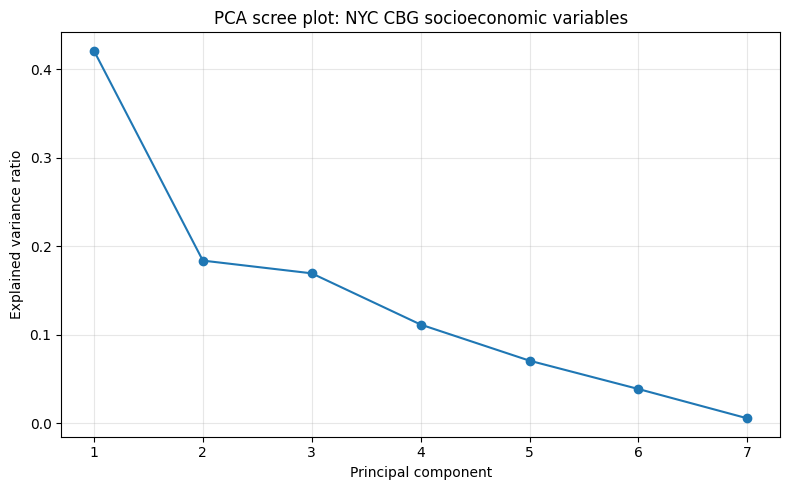

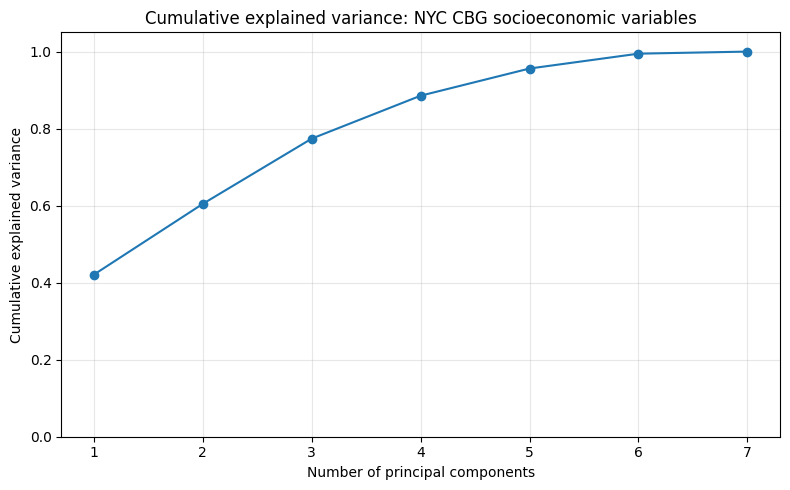

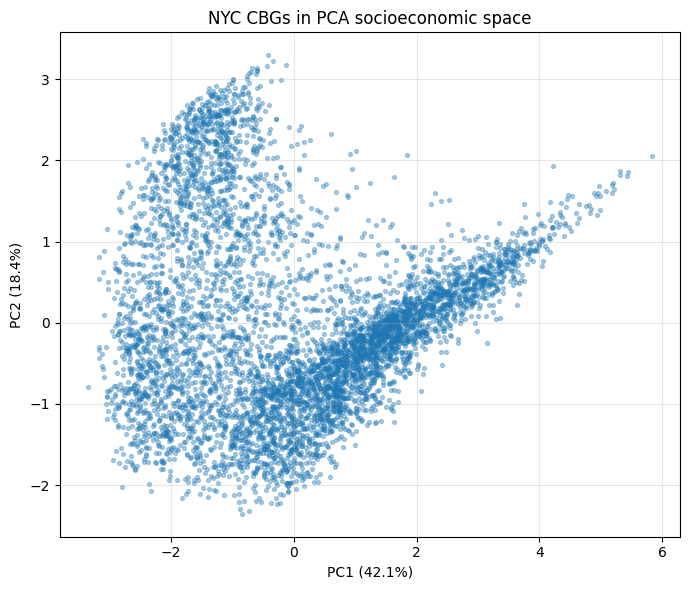


Saved PCA outputs:
outputs/pca_explained_variance.csv
outputs/pca_loadings.csv
outputs/pca_scores.csv


In [8]:
# ============================================================
# PCA of NYC CBG socioeconomic and demographic variables
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ------------------------------------------------------------
# 1. Use the same socioeconomic variables used in K-means
# ------------------------------------------------------------

socio_cols = [
    "med_ageE",
    "bachelor_degree_25E",
    "med_hh_incomeE",
    "whiteE",
    "blackE",
    "asianE",
    "hispanicE"
]

# df_kmeans_clean should already exist from the K-means section.
# It should include NYC CBGs only, with education/race/ethnicity variables converted to shares.
print("Rows used for PCA:", len(df_kmeans_clean))
print(df_kmeans_clean[socio_cols].describe())

# ------------------------------------------------------------
# 2. Standardize variables
# ------------------------------------------------------------

pca_scaler = StandardScaler()

X_pca_scaled = pca_scaler.fit_transform(df_kmeans_clean[socio_cols])

X_pca_scaled = pd.DataFrame(
    X_pca_scaled,
    columns=socio_cols,
    index=df_kmeans_clean.index
)

# ------------------------------------------------------------
# 3. Run PCA
# ------------------------------------------------------------

pca = PCA()
pca_scores = pca.fit_transform(X_pca_scaled)

pc_names = [f"PC{i+1}" for i in range(len(socio_cols))]

pca_scores_df = pd.DataFrame(
    pca_scores,
    columns=pc_names,
    index=df_kmeans_clean.index
)

# Attach CBG ID if available
if "census_block_group" in df_kmeans_clean.columns:
    pca_scores_df["census_block_group"] = df_kmeans_clean["census_block_group"].values
elif "cbg" in df_kmeans_clean.columns:
    pca_scores_df["cbg"] = df_kmeans_clean["cbg"].values

# ------------------------------------------------------------
# 4. Explained variance table
# ------------------------------------------------------------

pca_explained_variance = pd.DataFrame({
    "component": pc_names,
    "explained_variance_ratio": pca.explained_variance_ratio_,
    "cumulative_explained_variance": np.cumsum(pca.explained_variance_ratio_)
})

print("\nPCA explained variance:")
print(pca_explained_variance)

# ------------------------------------------------------------
# 5. PCA loadings table
# ------------------------------------------------------------

pca_loadings = pd.DataFrame(
    pca.components_.T,
    index=socio_cols,
    columns=pc_names
)

print("\nPCA loadings:")
print(pca_loadings)

# ------------------------------------------------------------
# 6. Scree plot
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(socio_cols) + 1),
    pca.explained_variance_ratio_,
    marker="o"
)
plt.xlabel("Principal component")
plt.ylabel("Explained variance ratio")
plt.title("PCA scree plot: NYC CBG socioeconomic variables")
plt.xticks(range(1, len(socio_cols) + 1))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 7. Cumulative explained variance plot
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(socio_cols) + 1),
    np.cumsum(pca.explained_variance_ratio_),
    marker="o"
)
plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance")
plt.title("Cumulative explained variance: NYC CBG socioeconomic variables")
plt.xticks(range(1, len(socio_cols) + 1))
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 8. Optional PC1-PC2 scatter plot
# ------------------------------------------------------------

plt.figure(figsize=(7, 6))
plt.scatter(
    pca_scores_df["PC1"],
    pca_scores_df["PC2"],
    s=8,
    alpha=0.35
)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
plt.title("NYC CBGs in PCA socioeconomic space")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 9. Save PCA outputs
# ------------------------------------------------------------

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

pca_explained_variance.to_csv(
    OUTPUT_DIR / "pca_explained_variance.csv",
    index=False
)

pca_loadings.to_csv(
    OUTPUT_DIR / "pca_loadings.csv"
)

pca_scores_df.to_csv(
    OUTPUT_DIR / "pca_scores.csv",
    index=False
)

print("\nSaved PCA outputs:")
print(OUTPUT_DIR / "pca_explained_variance.csv")
print(OUTPUT_DIR / "pca_loadings.csv")
print(OUTPUT_DIR / "pca_scores.csv")

## Moran's I for parameter change inspection

In [ ]:
# ============================================================
# Moran's I for CBG-level calibrated-parameter changes
# Uses four yearly PSO parameter files: 2018, 2019, 2020, 2021
# ============================================================

# If running in Colab and packages are missing, uncomment:
# !pip install geopandas libpysal esda shapely pyproj rtree -q

import json
import numpy as np
import pandas as pd
import geopandas as gpd

from libpysal.weights import Queen, KNN
from esda.moran import Moran, Moran_Local

# ------------------------------------------------------------
# 0. File paths
# ------------------------------------------------------------

BASE_DIR = "/content/drive/MyDrive/frontiers-rev/"

NYC_CBGS_JSON = BASE_DIR + "nyc_cbgs.json"

PSO_FILES = {
    2018: BASE_DIR + "PSO_2018_6params_NYC_norm_28_PSO_15.csv",
    2019: BASE_DIR + "PSO_2019_6params_NYC_norm_28_PSO_15.csv",
    2020: BASE_DIR + "PSO_2020_6params_NYC_norm_28_PSO_15.csv",
    2021: BASE_DIR + "PSO_2021_6params_NYC_norm_28_PSO_15.csv",
}

OUT_DIR = BASE_DIR

# ------------------------------------------------------------
# 1. Parameter columns from PSO files
# ------------------------------------------------------------

CBG_COL = "cbg"

PARAMETER_COLS = [
    "H_Area_of_store",
    "R_Percentage_of_Visits_by_brand",
    "J_POI_count_where_store_is",
    "K_POI_diversity_where_store_is",
    "L_Demographic_similarity",
    "G_Distance_between_cbg_and_store",
]

PARAMETER_LABELS = {
    "H_Area_of_store": "store_area",
    "R_Percentage_of_Visits_by_brand": "chain_loyalty",
    "J_POI_count_where_store_is": "poi_count",
    "K_POI_diversity_where_store_is": "poi_diversity",
    "L_Demographic_similarity": "demographic_similarity",
    "G_Distance_between_cbg_and_store": "distance",
}

# ------------------------------------------------------------
# 2. Load NYC CBG geometries
# ------------------------------------------------------------

gdf = gpd.read_file(NYC_CBGS_JSON)

print("NYC CBG geometry columns:")
print(gdf.columns.tolist())

if "GEOID" not in gdf.columns:
    raise ValueError("GEOID not found in nyc_cbgs.json. Check gdf.columns.tolist().")

gdf["GEOID"] = gdf["GEOID"].astype(str).str.zfill(12)

gdf = gdf[["GEOID", "geometry"]].copy()

print("\nNumber of NYC CBG geometries:", len(gdf))
print(gdf.head())

# ------------------------------------------------------------
# 3. Read and combine yearly PSO files
# ------------------------------------------------------------

params_list = []

for year, path in PSO_FILES.items():
    df_year = pd.read_csv(path)

    print(f"\nYear {year} columns:")
    print(df_year.columns.tolist())

    required_cols = [CBG_COL] + PARAMETER_COLS
    missing_cols = [c for c in required_cols if c not in df_year.columns]

    if missing_cols:
        raise ValueError(
            f"Missing columns in {year} file: {missing_cols}\n"
            f"Available columns are: {df_year.columns.tolist()}"
        )

    df_year = df_year[required_cols].copy()
    df_year["year"] = year

    df_year[CBG_COL] = df_year[CBG_COL].astype(str).str.zfill(12)

    params_list.append(df_year)

params = pd.concat(params_list, ignore_index=True)

print("\nCombined parameter data shape:", params.shape)
print(params.head())

print("\nCBG counts by year:")
print(params.groupby("year")[CBG_COL].nunique())

# ------------------------------------------------------------
# 4. Keep only CBGs present in all four years
# ------------------------------------------------------------

cbg_year_counts = params.groupby(CBG_COL)["year"].nunique()
complete_cbgs = cbg_year_counts[cbg_year_counts == 4].index

params = params[params[CBG_COL].isin(complete_cbgs)].copy()

print("\nNumber of CBGs present in all four years:", len(complete_cbgs))
print("Parameter data shape after keeping complete CBGs:", params.shape)

# ------------------------------------------------------------
# 5. Convert to wide format
# ------------------------------------------------------------

wide = params.pivot_table(
    index=CBG_COL,
    columns="year",
    values=PARAMETER_COLS,
    aggfunc="mean"
)

wide.columns = [f"{PARAMETER_LABELS[param]}_{year}" for param, year in wide.columns]
wide = wide.reset_index()

print("\nWide parameter data shape:", wide.shape)
print(wide.head())

# ------------------------------------------------------------
# 6. Compute year-to-year changes
# ------------------------------------------------------------

short_params = list(PARAMETER_LABELS.values())

for param in short_params:
    wide[f"{param}_change_2018_2019"] = wide[f"{param}_2019"] - wide[f"{param}_2018"]
    wide[f"{param}_change_2019_2020"] = wide[f"{param}_2020"] - wide[f"{param}_2019"]
    wide[f"{param}_change_2020_2021"] = wide[f"{param}_2021"] - wide[f"{param}_2020"]

change_cols = []

for param in short_params:
    change_cols.extend([
        f"{param}_change_2018_2019",
        f"{param}_change_2019_2020",
        f"{param}_change_2020_2021",
    ])

print("\nChange columns:")
print(change_cols)

print("\nParameter-change preview:")
print(wide[[CBG_COL] + change_cols].head())

# ------------------------------------------------------------
# 7. Merge with CBG geometries
# ------------------------------------------------------------

gdf_params = gdf.merge(
    wide,
    left_on="GEOID",
    right_on=CBG_COL,
    how="inner"
)

print("\nRows after merging geometries and parameters:", len(gdf_params))

gdf_params = gdf_params.replace([np.inf, -np.inf], np.nan)
gdf_params = gdf_params.dropna(subset=change_cols).copy()

print("Rows after dropping missing change values:", len(gdf_params))

# Save merged parameter-change data
gdf_params.drop(columns="geometry").to_csv(
    OUT_DIR + "cbg_parameter_changes_for_moran.csv",
    index=False
)

# ------------------------------------------------------------
# 8. Build spatial weights
# ------------------------------------------------------------

# Queen contiguity is standard for polygon CBGs.
w = Queen.from_dataframe(gdf_params, use_index=False)

print("\nNumber of islands with Queen weights:", len(w.islands))
print("Island indices, first 20:", w.islands[:20])

# If there are isolated CBGs, use KNN to avoid disconnected observations.
if len(w.islands) > 0:
    print("\nQueen weights have islands. Using KNN weights with k=5 instead.")
    w = KNN.from_dataframe(gdf_params, k=5)
else:
    print("\nUsing Queen contiguity weights.")

w.transform = "r"

# ------------------------------------------------------------
# 9. Global Moran's I for parameter changes
# ------------------------------------------------------------

moran_records = []

change_periods = [
    "change_2018_2019",
    "change_2019_2020",
    "change_2020_2021",
]

for param in short_params:
    for period in change_periods:
        col = f"{param}_{period}"

        y = gdf_params[col].astype(float).values

        moran = Moran(
            y,
            w,
            permutations=999
        )

        moran_records.append({
            "parameter": param,
            "period": period.replace("change_", ""),
            "n_cbgs": len(gdf_params),
            "moran_I": moran.I,
            "expected_I": moran.EI,
            "z_score": moran.z_sim,
            "p_value_permutation": moran.p_sim,
        })

moran_results = pd.DataFrame(moran_records)

print("\nGlobal Moran's I results:")
print(moran_results)

moran_results.to_csv(
    OUT_DIR + "moran_global_parameter_changes.csv",
    index=False
)

# ------------------------------------------------------------
# 10. Optional: Local Moran / LISA for 2019-2020 and 2020-2021
# ------------------------------------------------------------

lisa_records = []

for param in short_params:
    for period in ["change_2019_2020", "change_2020_2021"]:
        col = f"{param}_{period}"

        y = gdf_params[col].astype(float).values

        lisa = Moran_Local(
            y,
            w,
            permutations=999
        )

        temp = gdf_params[["GEOID"]].copy()
        temp["parameter"] = param
        temp["period"] = period.replace("change_", "")
        temp["local_I"] = lisa.Is
        temp["p_value"] = lisa.p_sim
        temp["quadrant"] = lisa.q

        quadrant_map = {
            1: "High-High",
            2: "Low-High",
            3: "Low-Low",
            4: "High-Low",
        }

        temp["lisa_cluster"] = temp["quadrant"].map(quadrant_map)
        temp["significant_005"] = temp["p_value"] < 0.05

        lisa_records.append(temp)

lisa_results = pd.concat(lisa_records, ignore_index=True)

print("\nLISA results preview:")
print(lisa_results.head())

lisa_results.to_csv(
    OUT_DIR + "lisa_local_parameter_changes.csv",
    index=False
)

# ------------------------------------------------------------
# 11. Print significant global Moran's I results
# ------------------------------------------------------------

sig_moran = moran_results[moran_results["p_value_permutation"] < 0.05].copy()

print("\nSignificant global Moran's I results at p < 0.05:")
print(sig_moran)

print("\nDone. Files saved:")
print(OUT_DIR + "cbg_parameter_changes_for_moran.csv")
print(OUT_DIR + "moran_global_parameter_changes.csv")
print(OUT_DIR + "lisa_local_parameter_changes.csv")